# Import Libraries

In [2]:
import pandas as pd
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [3]:
df = pd.read_csv("clean_data.csv")

df.head()

,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,hour_of_day,day_of_week,spam_label
0,1.924176,-0.284236,1.960029,0.959861,-0.446817,-0.364023,0.327518,0.100738,1.074541,-0.410937,2.0,0.0,0.0
1,-0.163476,0.337306,-0.510197,-0.696033,-0.446817,-0.364023,-1.468996,-2.183030,-0.470316,-1.501272,21.0,2.0,0.0
2,-0.645242,0.958849,-0.510197,-0.696033,-0.446817,-0.364023,0.327518,-1.663473,0.642191,-0.410937,13.0,5.0,0.0
3,-0.886125,0.958849,-0.510197,0.959861,-0.446817,-0.364023,0.327518,-0.344596,-0.106511,-0.592660,23.0,2.0,0.0
4,0.719761,1.580391,-0.510197,-0.696033,-0.446817,-0.364023,0.327518,-1.246685,2.039417,-0.229215,11.0,5.0,0.0


## Target Column

In [4]:
X = df.drop([
    'spam_label',
    'num_special_chars',
    'messages_sent_last_24h',
    'spam_keyword_score',
    'legit_keyword_score'
], axis=1)

y = df['spam_label']

## Train Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## Use Smote

In [7]:
print("Before SMOTE")

print(y_train.value_counts())

Before SMOTE
spam_label
0.0    3382
1.0     778
Name: count, dtype: int64


In [8]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [9]:
print("After SMOTE")

print(pd.Series(y_train_smote).value_counts())

After SMOTE
spam_label
1.0    3382
0.0    3382
Name: count, dtype: int64


## Train KNN

In [10]:
knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(
    X_train_smote,
    y_train_smote
)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


## Prediction

In [11]:
y_pred = knn.predict(
    X_test_scaled
)

## Accuracy

In [12]:
print(
    "Accuracy:",
    accuracy_score(y_test, y_pred)
)

Accuracy: 0.9548076923076924


## Classification Report

In [13]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

         0.0       0.99      0.95      0.97       845
         1.0       0.83      0.96      0.89       195

    accuracy                           0.95      1040
   macro avg       0.91      0.96      0.93      1040
weighted avg       0.96      0.95      0.96      1040



## Confusion Matrix

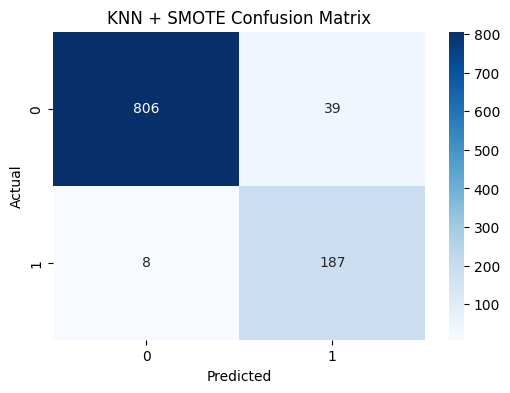

In [14]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("KNN + SMOTE Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## K Value Experiment

In [15]:
accuracy_scores = []

for k in range(1,21):

    model = KNeighborsClassifier(
        n_neighbors=k
    )

    model.fit(X_train_smote,y_train_smote)

    pred = model.predict(X_test_scaled)

    accuracy_scores.append(
        accuracy_score(
            y_test,
            pred
        )
    )

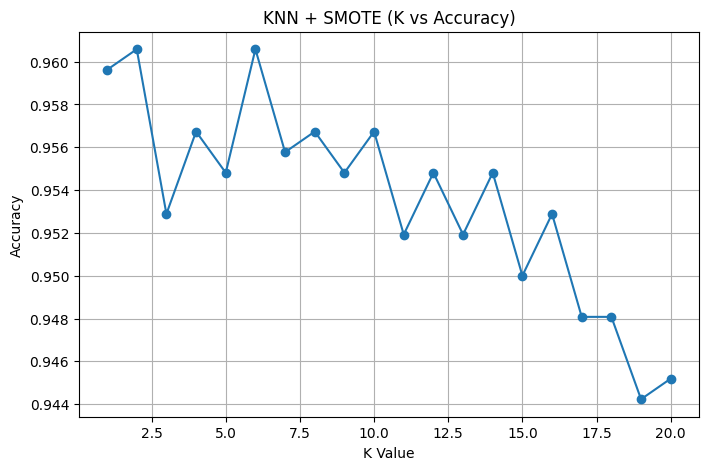

In [16]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,21),
    accuracy_scores,
    marker='o'
)

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN + SMOTE (K vs Accuracy)")
plt.grid()

plt.show()


## Distance Metric Comparison

In [17]:
metrics = ['euclidean','manhattan','minkowski']

for metric in metrics:

    model = KNeighborsClassifier(
        n_neighbors=5,
        metric=metric
    )

    model.fit(X_train_smote,y_train_smote)

    pred = model.predict(X_test_scaled)

    print(
        metric,
        "Accuracy:",
        accuracy_score(y_test,pred)
    )

euclidean Accuracy: 0.9548076923076924
manhattan Accuracy: 0.9557692307692308
minkowski Accuracy: 0.9548076923076924


## Misclassified Messages

In [18]:
misclassified = X_test.copy()

misclassified['Actual'] = y_test.values
misclassified['Predicted'] = y_pred

misclassified_cases = misclassified[
    misclassified['Actual']
    !=
    misclassified['Predicted']
]

print(
    "Total Misclassified Cases:",
    len(misclassified_cases)
)

misclassified_cases.head(10)

Total Misclassified Cases: 47


,message_length,word_count,num_urls,num_digits,sender_activity_score,sender_account_age_days,hour_of_day,day_of_week,Actual,Predicted
2292,-0.243770,1.580391,-0.510197,-0.696033,-1.006889,-0.169781,9.0,2.0,1.0,0.0
4971,-0.002888,1.580391,-0.510197,-0.696033,-0.190442,-1.066115,14.0,5.0,0.0,1.0
508,1.763588,2.201933,1.960029,0.959861,-1.138206,0.499833,13.0,2.0,0.0,1.0
1008,1.201527,-0.905778,1.960029,0.959861,0.226346,-0.375411,4.0,6.0,0.0,1.0
1628,-0.484653,1.580391,-0.510197,-0.696033,-0.002031,-1.282289,21.0,3.0,1.0,0.0
782,1.843882,-0.905778,1.960029,0.959861,0.232055,0.056938,21.0,0.0,0.0,1.0
4983,-1.046714,-0.905778,-0.510197,-0.696033,0.985699,-1.245381,18.0,5.0,1.0,0.0
3114,1.442410,-0.284236,1.960029,0.959861,-1.680601,-0.723399,6.0,3.0,0.0,1.0
422,-1.046714,-0.284236,-0.510197,1.373835,-0.087673,-1.445738,1.0,5.0,1.0,0.0
3249,2.405942,1.580391,1.960029,0.959861,-1.994619,-0.211962,22.0,5.0,0.0,1.0


# Conclusion

SMOTE was applied to balance the spam and legitimate message classes before training the KNN classifier. The balanced dataset improved the model's ability to identify spam messages, resulting in better Recall and F1-Score compared to training on the original imbalanced dataset.

 Different K values and distance metrics were evaluated to determine the optimal KNN configuration.